# S3.2 — Metric Ablation

Joint max-Z test with **p-value** detection:

$$T_{\text{obs}} = \max(Z_{\text{obs,dcor}},\; Z_{\text{obs,MIC}},\; \ldots)$$

$$p = \frac{1}{N_{\text{null}}} \sum_{j=1}^{N_{\text{null}}} \mathbf{1}(T_j \ge T_{\text{obs}})$$

$$p \le \alpha \;\Rightarrow\; \text{reject } H_0 \;\Rightarrow\; \text{detectable relationship}$$

In [66]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
})

S1_DIR = Path('output/S1')
S3_DIR = Path('output/S3')
OUT_DIR = Path('output/S3.2')
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05
USE_SPLIT         = True
TRAIN_FRACTION    = 0.5
RANDOM_SEED       = 20260623
EXCLUDE_BANDWIDTH = True
EXCLUDE_SLOPE     = True
EXCLUDE_RAW       = True
MERGE_DCOR_DCOV   = True

## §1 Load data & categories

In [67]:
df = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution']
cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

is_null = df['family_id'] == 'Null'
is_const = df['spread_pattern'] == 'constant'
df['category'] = 'mean+variance'
df.loc[is_null & is_const, 'category'] = 'true_null'
df.loc[is_null & ~is_const, 'category'] = 'variance_only'
df.loc[~is_null & is_const, 'category'] = 'mean_only'

print(f'Total: {len(df):,}')
print(df['category'].value_counts().to_string())

Total: 17,008
category
mean_only        5000
mean+variance    5000
true_null        4032
variance_only    2976


## §2 MINE-covered subset

In [68]:
MINE_COLS = [c for c in Z_COLS if any(c == f'z_{m}' for m in ['mic','mas','mev','mcn','mic_minus_r2','lowess_r2'])]
mine_covered = df[MINE_COLS].notna().all(axis=1)
df = df[mine_covered].copy()
Z_COLS = sorted([c for c in Z_COLS if df[c].notna().all()])
print(f'MINE-covered: {len(df):,}')
print(f'Z columns: {len(Z_COLS)}')

MINE-covered: 9,008
Z columns: 45


## §3 Metric groups & exclusions

In [69]:
METRIC_GROUPS = {}
METRIC_DISPLAY = {}

GROUP_DEFS = {
    'correlation': ['z_abs_pearson_r', 'z_abs_spearman_rho', 'z_abs_covariance'],
    'distance':    ['z_dcor', 'z_dcov'],
    'mine':        ['z_mic', 'z_mas', 'z_mev', 'z_mcn', 'z_mic_minus_r2'],
    'bin':         [c for c in Z_COLS if 'bin' in c],
    'distribution':['z_ec_dist_ks', 'z_ec_dist_wass', 'z_ew_dist_ks', 'z_ew_dist_wass'],
    'nonlinear':   ['z_lowess_r2'],
    'slope':       [c for c in Z_COLS if 'ep_' in c or 'pf_' in c or 'seg_' in c],
}
for g, cols in GROUP_DEFS.items():
    for c in cols:
        if c in Z_COLS:
            METRIC_GROUPS[c] = g

NICE = {
    'z_abs_pearson_r': '|Pearson|', 'z_abs_spearman_rho': '|Spearman|',
    'z_abs_covariance': 'Covariance',
    'z_dcor': 'dcor', 'z_dcov': 'dcov',
    'z_mic': 'MIC', 'z_mas': 'MAS', 'z_mev': 'MEV', 'z_mcn': 'MCN',
    'z_mic_minus_r2': 'MIC-r2',
    'z_ec_bin_eta2': 'eta2(EC)', 'z_ew_bin_eta2': 'eta2(EW)',
    'z_ec_dist_ks': 'KS(EC)', 'z_ec_dist_wass': 'Wass(EC)',
    'z_ew_dist_ks': 'KS(EW)', 'z_ew_dist_wass': 'Wass(EW)',
    'z_lowess_r2': 'LOWESS R2',
}
for c in Z_COLS:
    METRIC_DISPLAY[c] = NICE.get(c, c.replace('z_', ''))

SAFE_METRICS = [c for c in Z_COLS if c in METRIC_GROUPS]

if EXCLUDE_SLOPE:
    n = len(SAFE_METRICS)
    SAFE_METRICS = [m for m in SAFE_METRICS if METRIC_GROUPS.get(m) != 'slope']
    print(f'EXCLUDE_SLOPE: {n} -> {len(SAFE_METRICS)}')

if EXCLUDE_RAW:
    raw_patterns = ['z_abs_raw_', 'z_raw_seg', 'z_abs_covariance']
    amp = [m for m in SAFE_METRICS if '_bin_amp' in m]
    raw = [m for m in SAFE_METRICS if any(m.startswith(p) for p in raw_patterns)] + amp
    n = len(SAFE_METRICS)
    SAFE_METRICS = [m for m in SAFE_METRICS if m not in raw]
    print(f'EXCLUDE_RAW: {n} -> {len(SAFE_METRICS)}')

if EXCLUDE_BANDWIDTH:
    n = len(SAFE_METRICS)
    SAFE_METRICS = [m for m in SAFE_METRICS if '_bin_bw_' not in m]
    print(f'EXCLUDE_BANDWIDTH: {n} -> {len(SAFE_METRICS)}')

if MERGE_DCOR_DCOV:
    if 'z_dcov' in SAFE_METRICS:
        SAFE_METRICS.remove('z_dcov')
        print('MERGE_DCOR_DCOV: removed z_dcov')

if 'z_mcn' in SAFE_METRICS:
    SAFE_METRICS.remove('z_mcn')
    print('Removed MCN (degenerate)')

print(f'\nFinal: {len(SAFE_METRICS)} metrics')
for m in SAFE_METRICS:
    print(f'  {METRIC_DISPLAY[m]:15s}  ({METRIC_GROUPS[m]})')

EXCLUDE_SLOPE: 45 -> 27
EXCLUDE_RAW: 27 -> 24
EXCLUDE_BANDWIDTH: 24 -> 16
MERGE_DCOR_DCOV: removed z_dcov
Removed MCN (degenerate)

Final: 14 metrics
  |Pearson|        (correlation)
  |Spearman|       (correlation)
  dcor             (distance)
  eta2(EC)         (bin)
  KS(EC)           (distribution)
  Wass(EC)         (distribution)
  eta2(EW)         (bin)
  KS(EW)           (distribution)
  Wass(EW)         (distribution)
  LOWESS R2        (nonlinear)
  MAS              (mine)
  MEV              (mine)
  MIC              (mine)
  MIC-r2           (mine)


## §4 Train / Validation split

In [70]:
if USE_SPLIT:
    rng = np.random.default_rng(RANDOM_SEED)
    df['split'] = 'validation'
    for _, idx in df.groupby(['category', 'x_distribution'], dropna=False).groups.items():
        idx = np.array(list(idx)).copy()
        rng.shuffle(idx)
        n_train = max(1, min(int(round(len(idx) * TRAIN_FRACTION)), len(idx) - 1))
        df.loc[idx[:n_train], 'split'] = 'train'
    train = df[df['split'] == 'train'].copy()
    validation = df[df['split'] == 'validation'].copy()
    print(df.groupby(['split', 'category']).size().unstack(fill_value=0))
else:
    df['split'] = 'all'
    train = df.copy()
    validation = df.copy()
    print(f'USE_SPLIT=False: all {len(df):,} cases')

POWER_LABEL = 'Validation Power' if USE_SPLIT else 'Power'

category    mean+variance  mean_only  true_null  variance_only
split                                                         
train                 511        493       2016           1488
validation            507        489       2016           1488


## §5 Evaluation: max-Z + p-value

$$T_i = \max_{m \in S}(Z_{i,m}) \qquad p_i = \frac{\#\{j \in \text{null}: T_j \ge T_i\}}{N_{\text{null}}} \qquad \text{reject if } p_i \le \alpha$$

In [71]:
def get_null_T(data, z_metrics):
    null = data[data['category'] == 'true_null']
    return np.sort(null[z_metrics].max(axis=1).dropna().values)

def pvalues_from_null(T_obs, null_T_sorted):
    n = len(null_T_sorted)
    ranks = np.searchsorted(null_T_sorted, T_obs.values, side='left')
    return pd.Series(1.0 - ranks / n, index=T_obs.index)

def evaluate(z_metrics, data_fit, data_eval, alpha=ALPHA):
    null_T = get_null_T(data_fit, z_metrics)
    T = data_eval[z_metrics].max(axis=1)
    p = pvalues_from_null(T, null_T)
    detected = p <= alpha
    out = {}
    for cat in ['true_null', 'mean_only', 'variance_only', 'mean+variance']:
        mask = data_eval['category'] == cat
        out[f'rate_{cat}'] = float(detected[mask].mean()) if mask.sum() else np.nan
    signal = data_eval['category'] != 'true_null'
    out['overall_power'] = float(detected[signal].mean())
    return out

def make_row(z_metrics, label=None, kind=None):
    z_metrics = list(z_metrics)
    tr = evaluate(z_metrics, train, train)
    va = evaluate(z_metrics, train, validation)
    rates = [va['rate_mean_only'], va['rate_variance_only'], va['rate_mean+variance']]
    rates = [r for r in rates if not np.isnan(r)]
    return {
        'label': label or ', '.join(METRIC_DISPLAY[m] for m in z_metrics),
        'kind': kind, 'k': len(z_metrics),
        'metrics': ','.join(z_metrics),
        'display_metrics': ', '.join(METRIC_DISPLAY[m] for m in z_metrics),
        'validation_overall_power': va['overall_power'],
        'validation_macro_power': float(np.mean(rates)),
        'validation_FPR': va['rate_true_null'],
        'validation_MO': va['rate_mean_only'],
        'validation_VO': va['rate_variance_only'],
        'validation_MV': va['rate_mean+variance'],
        'train_overall_power': tr['overall_power'],
        'train_FPR': tr['rate_true_null'],
    }

print('Ready: T=max(Z), p=P(T_null>=T_obs), reject if p<=alpha')

Ready: T=max(Z), p=P(T_null>=T_obs), reject if p<=alpha


## §6 Baseline

In [72]:
baseline = make_row(SAFE_METRICS, label='all_safe', kind='baseline')
FULL_POWER = baseline['validation_overall_power']
print(f'All {len(SAFE_METRICS)} metrics:')
print(f'  Power = {FULL_POWER:.4f},  FPR = {baseline["validation_FPR"]:.4f}')

All 14 metrics:
  Power = 0.9754,  FPR = 0.0456


## §7 Individual metric power

In [73]:
individual_rows = []
for m in SAFE_METRICS:
    row = make_row([m], label=METRIC_DISPLAY[m], kind='individual')
    row['group'] = METRIC_GROUPS[m]
    individual_rows.append(row)

individual = pd.DataFrame(individual_rows).sort_values('validation_overall_power', ascending=False)
individual.to_csv(OUT_DIR / 'individual_metrics.csv', index=False, float_format='%.6f')

cols = ['label','group','validation_overall_power','validation_FPR',
        'validation_MO','validation_VO','validation_MV']
print(individual[cols].to_string(index=False, float_format='{:.3f}'.format))

     label        group  validation_overall_power  validation_FPR  validation_MO  validation_VO  validation_MV
      dcor     distance                     0.984           0.042          0.955          0.989          0.998
       MIC         mine                     0.919           0.053          0.908          0.902          0.978
       MEV         mine                     0.870           0.053          0.908          0.821          0.976
    KS(EW) distribution                     0.842           0.052          0.926          0.772          0.968
    KS(EC) distribution                     0.837           0.055          0.922          0.766          0.961
  Wass(EC) distribution                     0.835           0.058          0.937          0.759          0.963
  Wass(EW) distribution                     0.833           0.049          0.926          0.757          0.963
       MAS         mine                     0.760           0.039          0.440          0.897          0.667
 

## §8 Group ablation

In [74]:
groups = sorted(set(METRIC_GROUPS[m] for m in SAFE_METRICS))
group_rows = []

for g in groups:
    gm = [m for m in SAFE_METRICS if METRIC_GROUPS[m] == g]
    if gm:
        row = make_row(gm, label=f'{g} only', kind='group_only')
        row['group'] = g
        group_rows.append(row)

for g in groups:
    rest = [m for m in SAFE_METRICS if METRIC_GROUPS[m] != g]
    if rest:
        row = make_row(rest, label=f'all - {g}', kind='leave_group')
        row['group'] = g
        row['power_drop'] = FULL_POWER - row['validation_overall_power']
        group_rows.append(row)

group_ablation = pd.DataFrame(group_rows)
group_ablation.to_csv(OUT_DIR / 'group_ablation.csv', index=False, float_format='%.6f')

print('=== Group-only ===')
go = group_ablation[group_ablation['kind']=='group_only']
print(go[['label','validation_overall_power','validation_FPR']].to_string(index=False, float_format='{:.3f}'.format))
print()
print('=== Leave-one-group-out ===')
lg = group_ablation[group_ablation['kind']=='leave_group'].sort_values('power_drop', ascending=False)
print(lg[['label','validation_overall_power','power_drop']].to_string(index=False, float_format='{:.4f}'.format))

=== Group-only ===
            label  validation_overall_power  validation_FPR
         bin only                     0.452           0.046
 correlation only                     0.496           0.042
    distance only                     0.984           0.042
distribution only                     0.857           0.045
        mine only                     0.917           0.044
   nonlinear only                     0.437           0.053

=== Leave-one-group-out ===
             label  validation_overall_power  power_drop
    all - distance                    0.9497      0.0258
        all - mine                    0.9722      0.0032
 all - correlation                    0.9754      0.0000
all - distribution                    0.9754      0.0000
   all - nonlinear                    0.9771     -0.0016
         all - bin                    0.9779     -0.0024


## §9 Backward elimination

Remove the metric whose absence gives the highest power.  
With max-Z, fewer metrics = lower multiple-comparison penalty = power can increase.

In [75]:
remaining = list(SAFE_METRICS)
backward_rows = []

row0 = make_row(remaining, label=f'k={len(remaining)} (all)', kind='backward')
row0['removed_metric'] = ''
row0['removed_display'] = '(start)'
backward_rows.append(row0)

while len(remaining) > 1:
    best_power = -1
    best_to_remove = None
    for c in remaining:
        sub = [m for m in remaining if m != c]
        row = make_row(sub, kind='backward')
        if row['validation_overall_power'] > best_power:
            best_power = row['validation_overall_power']
            best_to_remove = c
            best_row = row
    remaining.remove(best_to_remove)
    best_row['label'] = f'k={len(remaining)}'
    best_row['removed_metric'] = best_to_remove
    best_row['removed_display'] = METRIC_DISPLAY[best_to_remove]
    backward_rows.append(best_row)

backward = pd.DataFrame(backward_rows)
backward['power_change'] = backward['validation_overall_power'].diff()
backward.to_csv(OUT_DIR / 'backward_elimination.csv', index=False, float_format='%.6f')

print(backward[['k','removed_display','validation_overall_power','validation_FPR','power_change']].to_string(
    index=False, float_format='{:.4f}'.format))

 k removed_display  validation_overall_power  validation_FPR  power_change
14         (start)                    0.9754          0.0456           NaN
13        eta2(EC)                    0.9779          0.0461        0.0024
12       LOWESS R2                    0.9803          0.0561        0.0024
11      |Spearman|                    0.9803          0.0561        0.0000
10          KS(EC)                    0.9803          0.0556        0.0000
 9             MEV                    0.9803          0.0556        0.0000
 8             MIC                    0.9803          0.0556        0.0000
 7          MIC-r2                    0.9807          0.0580        0.0004
 6        Wass(EW)                    0.9811          0.0600        0.0004
 5       |Pearson|                    0.9819          0.0605        0.0008
 4          KS(EW)                    0.9819          0.0595        0.0000
 3             MAS                    0.9823          0.0541        0.0004
 2        Wass(EC)       

## §10 Forward search

In [76]:
best_single = individual.iloc[0]
selected = [best_single['metrics']]
forward_rows = []

row = make_row(selected, label='k=1', kind='forward')
row['added_display'] = METRIC_DISPLAY[selected[0]]
forward_rows.append(row)

candidates = [m for m in SAFE_METRICS if m not in selected]
while candidates:
    best_power = -1
    best_to_add = None
    for c in candidates:
        sub = selected + [c]
        row = make_row(sub, kind='forward')
        if row['validation_overall_power'] > best_power:
            best_power = row['validation_overall_power']
            best_to_add = c
            best_row = row
    selected.append(best_to_add)
    candidates.remove(best_to_add)
    best_row['label'] = f'k={len(selected)}'
    best_row['added_display'] = METRIC_DISPLAY[best_to_add]
    forward_rows.append(best_row)

forward = pd.DataFrame(forward_rows)
forward['power_change'] = forward['validation_overall_power'].diff()
forward.to_csv(OUT_DIR / 'forward_selection.csv', index=False, float_format='%.6f')

print(forward[['k','added_display','validation_overall_power','validation_FPR','power_change']].to_string(
    index=False, float_format='{:.4f}'.format))

 k added_display  validation_overall_power  validation_FPR  power_change
 1          dcor                    0.9839          0.0417           NaN
 2     |Pearson|                    0.9835          0.0437       -0.0004
 3      Wass(EW)                    0.9823          0.0476       -0.0012
 4           MIC                    0.9827          0.0516        0.0004
 5      eta2(EW)                    0.9827          0.0476        0.0000
 6           MEV                    0.9827          0.0476        0.0000
 7    |Spearman|                    0.9815          0.0481       -0.0012
 8        KS(EC)                    0.9815          0.0481        0.0000
 9        MIC-r2                    0.9815          0.0496        0.0000
10      Wass(EC)                    0.9803          0.0516       -0.0012
11        KS(EW)                    0.9799          0.0531       -0.0004
12           MAS                    0.9803          0.0561        0.0004
13     LOWESS R2                    0.9779         

## §11 Visualization

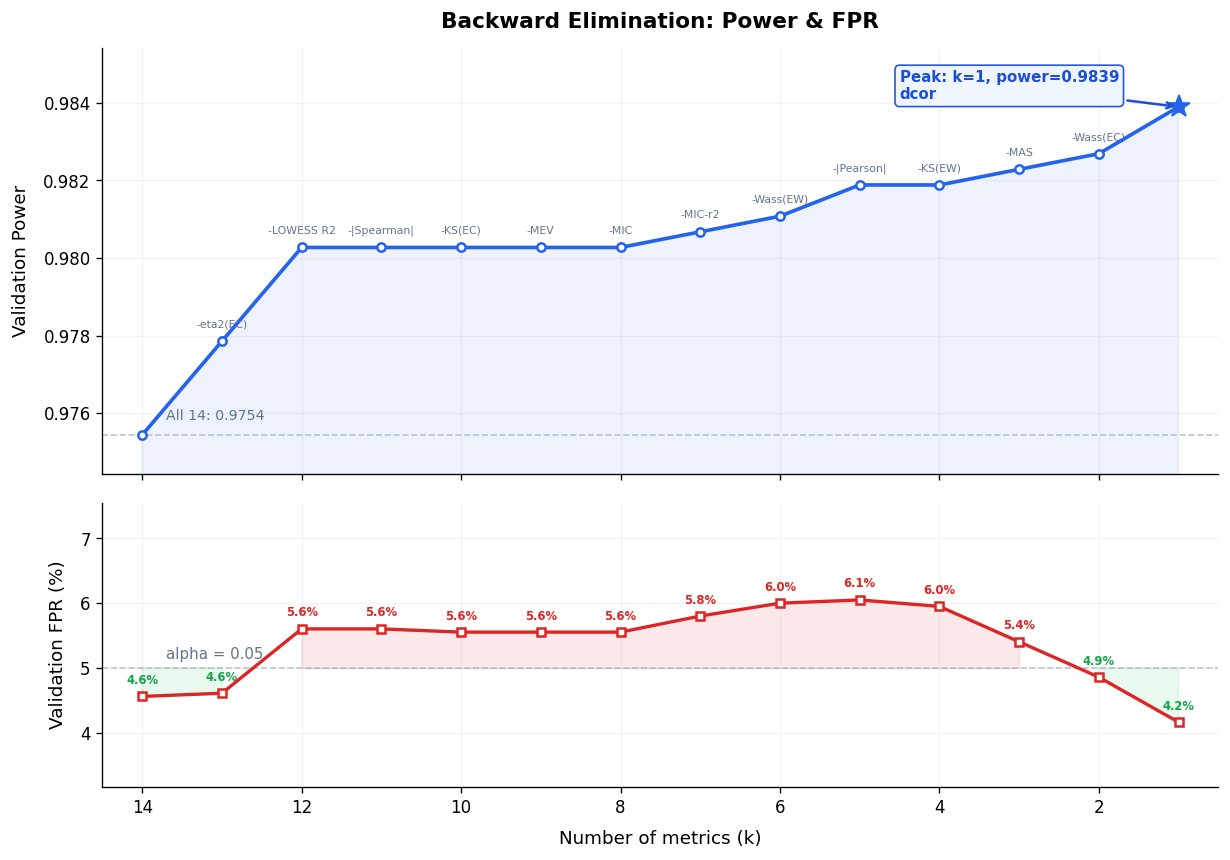

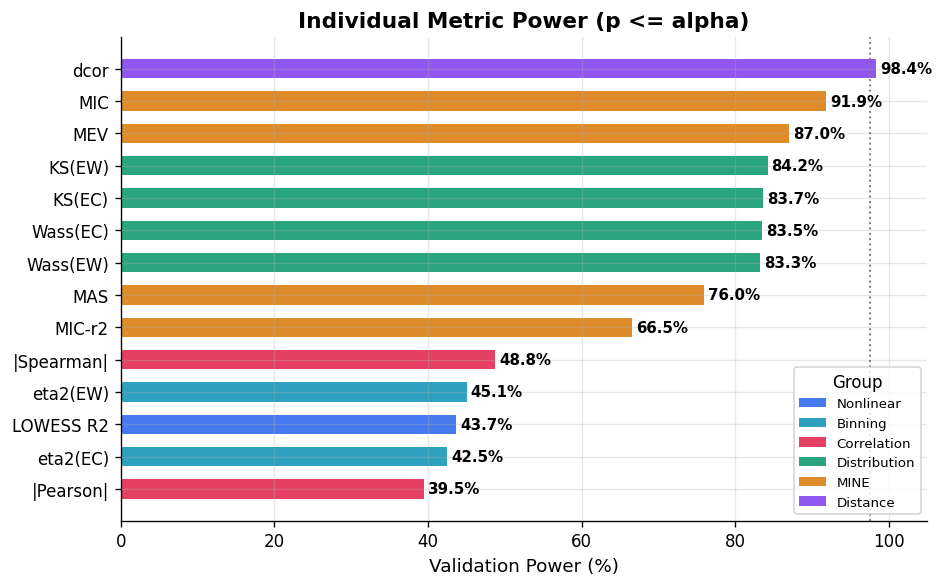

In [77]:
from matplotlib.patches import Patch

GROUP_COLORS = {
    'correlation': '#e11d48', 'distance': '#7c3aed', 'slope': '#64748b',
    'bin': '#0891b2', 'distribution': '#059669', 'mine': '#d97706', 'nonlinear': '#2563eb',
}
GROUP_LABELS = {
    'correlation': 'Correlation', 'distance': 'Distance',
    'bin': 'Binning', 'distribution': 'Distribution', 'mine': 'MINE', 'nonlinear': 'Nonlinear',
}

# ═══════════════════════════════════════════════════
# Figure 1: Backward elimination — Power + FPR
# ═══════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.08})

bk = backward.copy()
ks = bk['k'].values
powers = bk['validation_overall_power'].values
fprs = bk['validation_FPR'].values
k_max = int(ks[0])

# ── Top: Power ──
ax1.fill_between(ks, powers, alpha=0.08, color='#2563eb')
ax1.plot(ks, powers, '-o', color='#2563eb', markersize=5, lw=2.2, zorder=4,
         markerfacecolor='white', markeredgewidth=1.5)

full_power = powers[0]
ax1.axhline(full_power, color='#94a3b8', ls='--', lw=1, alpha=0.6)
ax1.text(k_max - 0.3, full_power + 0.0003, f'All {k_max}: {full_power:.4f}',
         fontsize=8.5, color='#64748b', ha='left', va='bottom')

peak_idx = bk['validation_overall_power'].idxmax()
peak_row = bk.loc[peak_idx]
peak_k = int(peak_row['k'])
peak_power = peak_row['validation_overall_power']
ax1.plot(peak_k, peak_power, '*', color='#2563eb', markersize=14, zorder=6)
ax1.annotate(
    f'Peak: k={peak_k}, power={peak_power:.4f}\n{peak_row["display_metrics"]}',
    xy=(peak_k, peak_power),
    xytext=(peak_k + 3.5, peak_power + 0.0002),
    fontsize=9, color='#1d4ed8', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#eff6ff', edgecolor='#1d4ed8', alpha=0.95),
    zorder=7)

for _, row in bk.iterrows():
    k = int(row['k'])
    if row['removed_display'] == '(start)' or k == peak_k:
        continue
    ax1.text(k, row['validation_overall_power'] + 0.0003, f'-{row["removed_display"]}',
             fontsize=6.5, color='#64748b', ha='center', va='bottom')

ax1.set_ylabel(POWER_LABEL, fontsize=11, labelpad=8)
ax1.set_title('Backward Elimination: Power & FPR', fontsize=13, fontweight='bold', pad=12)
yr = powers.max() - powers.min()
ax1.set_ylim(powers.min() - yr * 0.12, powers.max() + yr * 0.18)
ax1.grid(True, alpha=0.15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(labelsize=10)

# ── Bottom: FPR ──
ax2.plot(ks, fprs * 100, '-s', color='#dc2626', markersize=5, lw=2, zorder=4,
         markerfacecolor='white', markeredgewidth=1.5)
ax2.axhline(ALPHA * 100, color='#94a3b8', ls='--', lw=1, alpha=0.6)
ax2.text(k_max - 0.3, ALPHA * 100 + 0.15, f'alpha = {ALPHA}', fontsize=9, color='#64748b')

ax2.fill_between(ks, fprs * 100, ALPHA * 100, alpha=0.1,
                 color='#dc2626', where=fprs * 100 > ALPHA * 100)
ax2.fill_between(ks, fprs * 100, ALPHA * 100, alpha=0.1,
                 color='#22c55e', where=fprs * 100 <= ALPHA * 100)

for k_val, fpr_val in zip(ks, fprs):
    color = '#dc2626' if fpr_val > ALPHA else '#16a34a'
    ax2.text(k_val, fpr_val * 100 + 0.15, f'{fpr_val*100:.1f}%',
             fontsize=7, ha='center', va='bottom', color=color, fontweight='bold')

ax2.set_xlabel('Number of metrics (k)', fontsize=11, labelpad=8)
ax2.set_ylabel('Validation FPR (%)', fontsize=11, labelpad=8)
ax2.set_xlim(k_max + 0.5, 0.5)
fpr_lo = min(fprs.min() * 100 - 1, ALPHA * 100 - 1.5)
fpr_hi = max(fprs.max() * 100 + 1.5, ALPHA * 100 + 1.5)
ax2.set_ylim(fpr_lo, fpr_hi)
ax2.grid(True, alpha=0.15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(labelsize=10)

fig.savefig(OUT_DIR / 'fig1_backward_elimination.png', dpi=200, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════
# Figure 2: Individual metric power
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ind = individual.sort_values('validation_overall_power', ascending=True)
names = ind['label'].values
powers_i = ind['validation_overall_power'].values * 100
colors = [GROUP_COLORS.get(g, '#999') for g in ind['group'].values]

ax.barh(range(len(names)), powers_i, color=colors, alpha=0.85, height=0.6)
for ii, p in enumerate(powers_i):
    ax.text(p + 0.5, ii, f'{p:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.axvline(FULL_POWER * 100, color='gray', ls=':', lw=1.2)
ax.set_xlabel(f'{POWER_LABEL} (%)', fontsize=11)
ax.set_xlim(0, 105)
ax.set_title('Individual Metric Power (p <= alpha)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

seen, handles = [], []
for g in ind['group'].values[::-1]:
    if g not in seen:
        seen.append(g)
        handles.append(Patch(facecolor=GROUP_COLORS.get(g,'#999'), label=GROUP_LABELS.get(g,g), alpha=0.85))
ax.legend(handles=handles[::-1], fontsize=8, loc='lower right', title='Group')
plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_individual_power.png', dpi=200, bbox_inches='tight')
plt.show()

## §12 Summary

In [78]:
print('=' * 70)
print('S3.2 Metric Ablation Summary')
print('=' * 70)
print(f'Method: T=max(Z), p=P(T_null>=T_obs), reject if p<={ALPHA}')
print(f'Cases: {len(df):,},  Metrics: {len(SAFE_METRICS)}')
print()
print(f'Baseline (all {len(SAFE_METRICS)}): Power={FULL_POWER:.4f}, FPR={baseline["validation_FPR"]:.4f}')
print()
peak = backward.loc[backward['validation_overall_power'].idxmax()]
print(f'Peak: k={int(peak["k"])}, metric={peak["display_metrics"]}, Power={peak["validation_overall_power"]:.4f}')
print(f'Delta vs all: {peak["validation_overall_power"] - FULL_POWER:+.4f}')
print()
print('Backward elimination:')
for _, r in backward.iterrows():
    if r['removed_display'] == '(start)': continue
    print(f'  k={int(r["k"]):2d} -{r["removed_display"]:15s} power={r["validation_overall_power"]:.4f} ({r["power_change"]:+.4f})')

S3.2 Metric Ablation Summary
Method: T=max(Z), p=P(T_null>=T_obs), reject if p<=0.05
Cases: 9,008,  Metrics: 14

Baseline (all 14): Power=0.9754, FPR=0.0456

Peak: k=1, metric=dcor, Power=0.9839
Delta vs all: +0.0085

Backward elimination:
  k=13 -eta2(EC)        power=0.9779 (+0.0024)
  k=12 -LOWESS R2       power=0.9803 (+0.0024)
  k=11 -|Spearman|      power=0.9803 (+0.0000)
  k=10 -KS(EC)          power=0.9803 (+0.0000)
  k= 9 -MEV             power=0.9803 (+0.0000)
  k= 8 -MIC             power=0.9803 (+0.0000)
  k= 7 -MIC-r2          power=0.9807 (+0.0004)
  k= 6 -Wass(EW)        power=0.9811 (+0.0004)
  k= 5 -|Pearson|       power=0.9819 (+0.0008)
  k= 4 -KS(EW)          power=0.9819 (+0.0000)
  k= 3 -MAS             power=0.9823 (+0.0004)
  k= 2 -Wass(EC)        power=0.9827 (+0.0004)
  k= 1 -eta2(EW)        power=0.9839 (+0.0012)
